# SEALS -- spectrally encoding a scattering pattern into a spectrum
### map scattering angle theta -> wavelength lambda, then read it on a spectrometer

**SEALS** (Spectrally Encoded Angular Light Scattering) uses a dual-grating element
so that light scattered at each angle leaves at a different **wavelength**. A single
spectrometer trace then carries the whole angular scattering pattern -- no moving
detector. This notebook builds the two numpy-only halves: the **grating mapping**
lambda -> theta, and **Rayleigh-Debye-Gans** scattering (with a calculus cameo: the
form factor's 0/0 limit). The full Lorenz-Mie / 3D / OAM treatment is in
`seals_stable.ipynb` (needs scipy, py-3.12).

In [1]:
import numpy as np, matplotlib.pyplot as plt
# default SEALS parameters (telecom C-band, 9.94 um particle)
d, D, a = 9.0909e-7, 0.065, 0.9023      # groove spacing, inter-grating distance, tilt
P, NA, dcorr, mangle = 0.0058, 0.70, -4.2448e-4, 20.0
lam = np.linspace(1580e-9, 1600e-9, 500)
print("ready")

ready


## 1. The grating mapping lambda -> theta

The diffracted angle obeys the grating equation $\sin\alpha+\sin\theta_d=\lambda/d$,
so $\theta_d=\arcsin(\lambda/d-\sin\alpha)$. After distance $D$ between two
gratings the beam lands at
$$y(\lambda)=\tfrac{1}{6}D\,\frac{\tan(\alpha-\theta_d)}{1+\tan(\alpha-\theta_d)\tan\alpha},$$
and a lens maps $y$ to the scattering angle. Each wavelength encodes one angle.

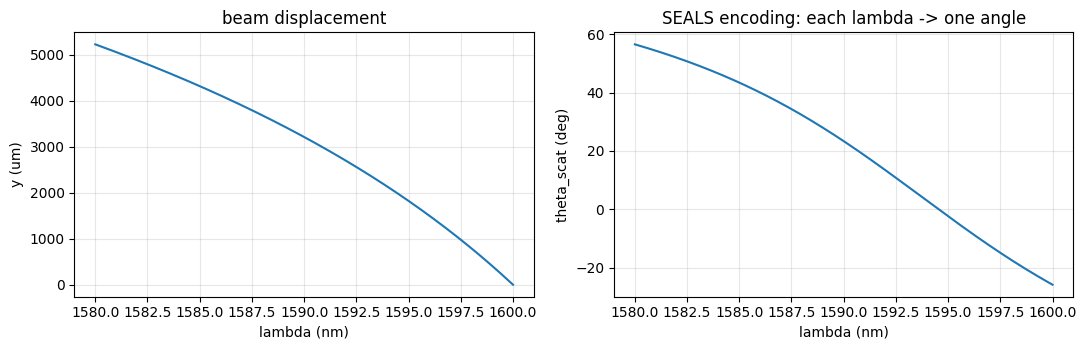

theta spans [-25.76, 56.50] deg across the 20 nm band


In [2]:
def seals_map(lam, d, D, a, P, NA, dcorr):
    theta_d = np.arcsin(np.clip(lam/d - np.sin(a), -0.9999, 0.9999))
    Delta = a - theta_d
    y = (D/6) * np.tan(Delta) / (1 + np.tan(Delta)*np.tan(a))   # tan(D)*tan(a), not tan^2
    y = y - y[-1]
    yc = (y[0]-y[-1])/2
    theta = np.degrees(np.arctan((2/P)*(y-yc+dcorr)*np.tan(np.arcsin(NA))))
    return y, theta

y, theta = seals_map(lam, d, D, a, P, NA, dcorr); theta += mangle
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(lam*1e9, y*1e6); ax[0].set(xlabel="lambda (nm)", ylabel="y (um)", title="beam displacement")
ax[1].plot(lam*1e9, theta); ax[1].set(xlabel="lambda (nm)", ylabel="theta_scat (deg)",
           title="SEALS encoding: each lambda -> one angle")
for x in ax: x.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"theta spans [{theta.min():.2f}, {theta.max():.2f}] deg across the 20 nm band")

## 2. Rayleigh-Debye-Gans scattering -- and a calculus cameo

For a soft sphere the scattered intensity is
$$I(\theta)\propto\Big|\tfrac{n^2-1}{n^2+2}\Big|^2\,(1+\cos^2\theta)\,P(\theta)^2,
\quad P(u)=\frac{3(\sin u-u\cos u)}{u^3},\ u=2ka\sin\tfrac{\theta}{2}.$$
At $\theta\to0$, $u\to0$ and $P=0/0$. The **Taylor series** resolves it:
$\sin u-u\cos u=\tfrac{u^3}{3}-\tfrac{u^5}{30}+\dots$, so
$P(u)=1-\tfrac{u^2}{10}+\dots\to 1$. Same limit-from-calculus that makes a
derivative well-defined -- here it saves the formula from a NaN.

P(u->0) = 1.0  (the 0/0 limit = 1, via Taylor)


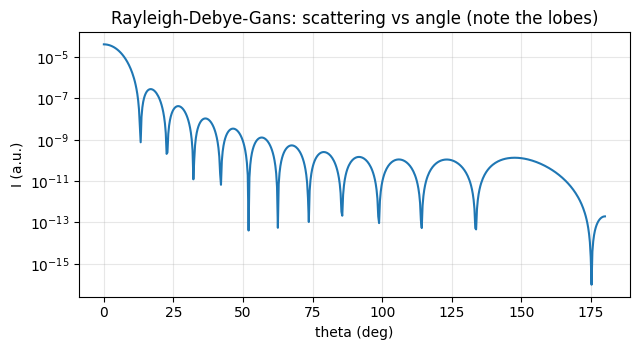

In [3]:
def form_factor_P(u):
    out = np.empty_like(u, float)
    small = np.abs(u) < 0.1
    us = u[small]; out[small] = 1 - us**2/10 + us**4/280       # Taylor near 0
    ul = u[~small]; out[~small] = 3*(np.sin(ul) - ul*np.cos(ul))/ul**3
    return out

def rdg_intensity(dia, lam0, n_bg, n_sp, theta_rad, R=0.1):
    aa = dia/2; k = 2*np.pi*n_bg/lam0; nr = n_sp/n_bg
    u = 2*k*aa*np.sin(theta_rad/2)
    P = form_factor_P(u); f = 1 + np.cos(theta_rad)**2
    return np.abs(P*f)**2 * ((nr**2-1)/(nr**2+2))**2 / (2*R**2) * (2*np.pi/lam0)**4 * aa**6

print("P(u->0) =", form_factor_P(np.array([0.0]))[0], " (the 0/0 limit = 1, via Taylor)")
th = np.linspace(1e-4, np.pi, 600)
I = rdg_intensity(9940e-9, 1590e-9, 1.0, 1.39, th)
plt.figure(figsize=(6.5,3.6))
plt.semilogy(np.degrees(th), I); plt.xlabel("theta (deg)"); plt.ylabel("I (a.u.)")
plt.title("Rayleigh-Debye-Gans: scattering vs angle (note the lobes)"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 3. Putting it together -- the SEALS readout

The spectrometer sees intensity at each wavelength, and each wavelength *is* an
angle. So $I_{\rm SEALS}(\lambda)=I_{\rm scat}(\theta(\lambda))$ -- the angular
scattering pattern, read out as a spectrum. That is the whole idea: **no goniometer,
one shot.**

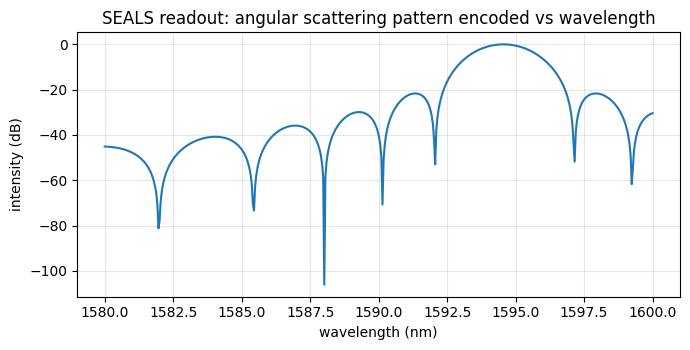

one spectrometer trace = the scattering pattern over -25.8-56.5 deg


In [4]:
theta_rad = np.clip(np.abs(np.radians(theta)), 1e-4, np.pi)
I_seals = rdg_intensity(9940e-9, 1590e-9, 1.0, 1.39, theta_rad)
plt.figure(figsize=(7,3.6))
plt.plot(lam*1e9, 10*np.log10(I_seals/I_seals.max()))
plt.xlabel("wavelength (nm)"); plt.ylabel("intensity (dB)")
plt.title("SEALS readout: angular scattering pattern encoded vs wavelength"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("one spectrometer trace = the scattering pattern over", f"{theta.min():.1f}-{theta.max():.1f} deg")

## Takeaway

1. A dual grating maps **wavelength -> scattering angle**, so a spectrum encodes an
   angular pattern (SEALS: no moving detector).
2. **Rayleigh-Debye-Gans** gives the soft-sphere scattering; its form factor's
   $0/0$ at $\theta=0$ is resolved by a **Taylor limit** ($P\to1$) -- calculus
   keeping the simulation finite.
3. Reading $I(\theta(\lambda))$ vs $\lambda$ is the SEALS measurement.

Full Lorenz-Mie (exact spheres), 3D patterns, and OAM decomposition are in
`seals_stable.ipynb`. Civilian education.